In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [2]:
df_energy = pd.read_parquet('sense_acute_climate.parquet')

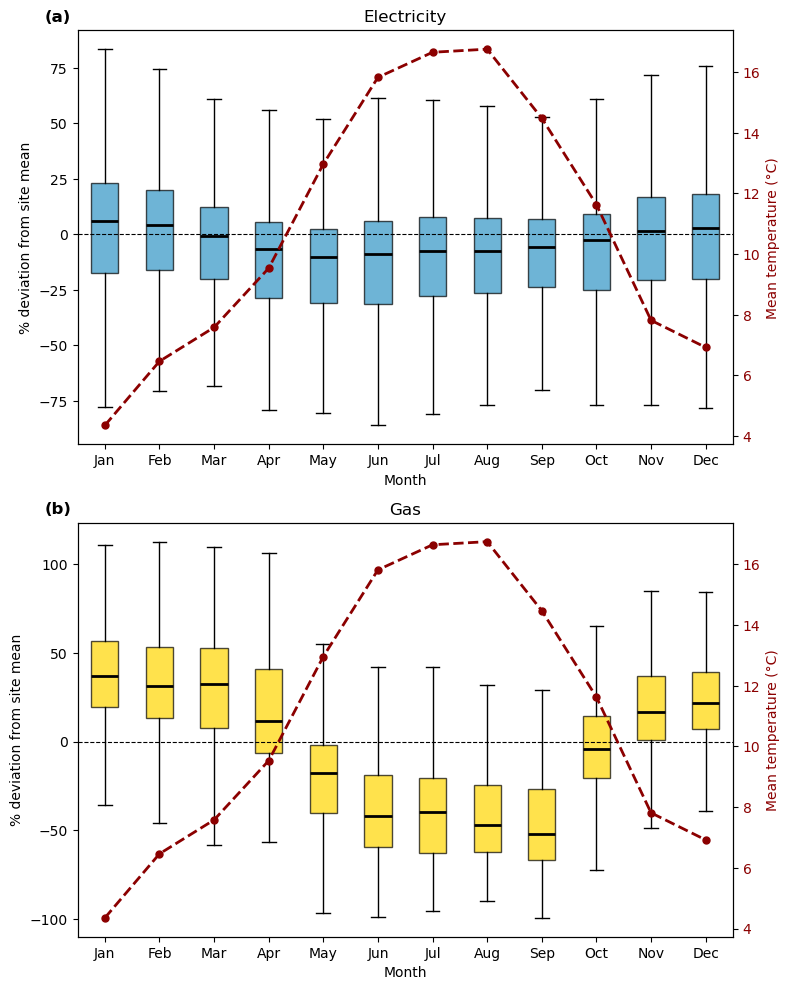

In [20]:
# Initial plot to show historical trend in energy consumption by month, with temperature

fig, axes = plt.subplots(2, 1, figsize=(8, 10))

months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_temp = df_energy.groupby('month')['tas'].mean()

for ax, energy, color, title, label in zip(
    axes,
    ['elec', 'gas'],
    ['#3195C5', 'gold'],
    ['Electricity', 'Gas'],
    ['(a)', '(b)']
):
    data = df_energy[(df_energy['energy_type'] == energy) & 
                     (df_energy['consumption'] > 0)].copy()
    site_means = data.groupby('site_code')['consumption'].transform('mean')
    data['normalised'] = (data['consumption'] - site_means) / site_means * 100
    
    monthly_data = [data[data['month'] == m]['normalised'].values for m in range(1, 13)]
    
    ax.boxplot(monthly_data,
               patch_artist=True,
               showfliers=False,
               boxprops=dict(facecolor=color, alpha=0.7),
               medianprops=dict(color='black', linewidth=2),
               whiskerprops=dict(color='black'),
               capprops=dict(color='black'))
    
    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
    ax.text(-0.05, 1.05, label, transform=ax.transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')
    
    ax2 = ax.twinx()
    ax2.plot(range(1, 13), monthly_temp.values,
             color='darkred', linewidth=2, linestyle='--',
             marker='o', markersize=5)
    ax2.set_ylabel('Mean temperature (°C)', color='darkred')
    ax2.tick_params(axis='y', labelcolor='darkred')
    
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(months)
    ax.set_xlabel('Month')
    ax.set_ylabel('% deviation from site mean')
    ax.set_title(title)
    

plt.tight_layout()
plt.show()

In [6]:
# sites with missing data
zero_summary = df_energy.groupby(['site_code', 'energy_type']).apply(
    lambda x: pd.Series({
        'total_days': len(x),
        'zero_days': (x['consumption'] == 0).sum(),
        '%': (x['consumption'] == 0).mean() * 100
    })
).reset_index()

print(zero_summary[zero_summary['%'] > 0].sort_values('%', ascending=False).to_string())

   site_code energy_type  total_days  zero_days           %
16     RFSDA         gas       412.0      412.0  100.000000
21     RH868         gas       705.0      290.0   41.134752
37     RN3G2        elec      1192.0      259.0   21.728188
32     RL131         gas       705.0      110.0   15.602837
0      R0A01         gas       396.0       43.0   10.858586
24     RH8K6         gas       705.0       42.0    5.957447
43     RXN02         gas       705.0       42.0    5.957447
40     RQXM1         gas       705.0       41.0    5.815603
18     RH801         gas       705.0       41.0    5.815603
36     RN325        elec      1192.0       47.0    3.942953
33     RLT01        elec      1192.0       22.0    1.845638
2      R0A06         gas       145.0        2.0    1.379310
20     RH868        elec      1248.0       13.0    1.041667
14     RD130         gas       452.0        4.0    0.884956
19     RH802        elec      1249.0        9.0    0.720576
22     RH880        elec       833.0    

C:\Users\alexd\AppData\Local\Temp\ipykernel_10168\2681643652.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  zero_summary = df_energy.groupby(['site_code', 'energy_type']).apply(


In [ ]:
print(df_energy[df_energy['site_code'] == 'RFSDA'][['site_name', 'organisation_name']].iloc[0])

### Note, there are still 9 gas sites, RFSDA has been excluded the whole time via consumption > 0, effectively excluding it from the analysis

site_name                                 Chesterfield  Royal Hospital
organisation_name    Chesterfield Royal Hospital NHS Foundation Trust 
Name: 12226, dtype: object


In [8]:
# Pearson correlation between consumption and climate features, averaged across sites, for each energy type

cols = ['consumption', 'tasmax', 'tasmin', 'tas', 'HDD', 'CDD', 
        'tas_lag1', 'tas_lag3', 'tas_7day_mean',
        'heatwave', 'extreme_cold', 'hurs', 'sfcWind', 'rsds']

all_corrs = []

for site in df_energy['site_code'].unique():
    for energy in ['elec', 'gas']:
        data = df_energy[(df_energy['site_code'] == site) & 
                         (df_energy['energy_type'] == energy) &
                         (df_energy['consumption'] > 0)].dropna(subset=cols)
        if len(data) > 30:
            corr = data[cols].corr(method='pearson')['consumption'].drop('consumption')
            corr['site_code'] = site
            corr['energy_type'] = energy
            all_corrs.append(corr)

corr_df = pd.DataFrame(all_corrs)

feature_cols = ['tasmax', 'tasmin', 'tas', 'HDD', 'CDD', 
                'tas_lag1', 'tas_lag3', 'tas_7day_mean',
                'heatwave', 'extreme_cold', 'hurs', 'sfcWind', 'rsds']

mean_corr = corr_df.groupby('energy_type')[feature_cols].mean().round(3)
std_corr = corr_df.groupby('energy_type')[feature_cols].std().round(3)

combined = pd.DataFrame(index=mean_corr.index)
for col in feature_cols:
    combined[col] = mean_corr[col].astype(str) + ' (±' + std_corr[col].astype(str) + ')'

combined.index.name = 'Energy type'
combined.columns = ['tasmax', 'tasmin', 'tas', 'HDD', 'CDD',
                    'tas_lag1', 'tas_lag3', 'tas_7day_mean',
                    'heatwave', 'extreme_cold', 'hurs', 'sfcWind', 'rsds']

combined_T = combined.T
combined_T.index.name = 'Feature'

from IPython.display import display
display(combined_T.style.set_caption('Mean Pearson correlations with consumption (mean ± std across sites)'))

combined_T.to_excel('correlation_table.xlsx')

Energy type,elec,gas
Feature,,
tasmax,-0.175 (±0.34),-0.683 (±0.199)
tasmin,-0.141 (±0.288),-0.64 (±0.158)
tas,-0.168 (±0.328),-0.704 (±0.181)
HDD,0.194 (±0.314),0.695 (±0.178)
CDD,0.035 (±0.102),-0.095 (±0.021)
tas_lag1,-0.172 (±0.322),-0.701 (±0.178)
tas_lag3,-0.17 (±0.3),-0.674 (±0.177)
tas_7day_mean,-0.182 (±0.326),-0.707 (±0.182)
heatwave,0.036 (±0.12),-0.161 (±0.071)


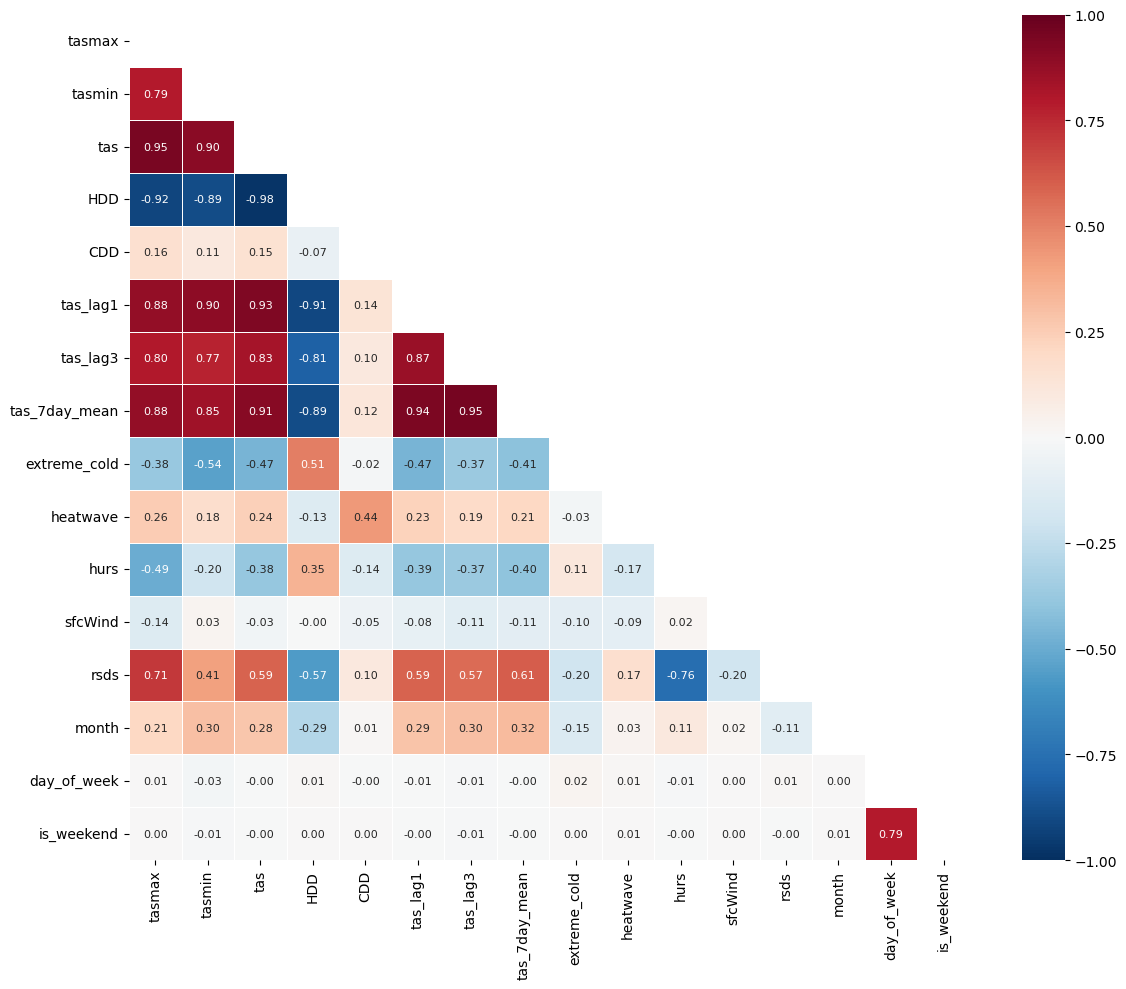

               tasmax  tasmin   tas   HDD   CDD  tas_lag1  tas_lag3  tas_7day_mean  extreme_cold  heatwave  hurs  sfcWind  rsds  month  day_of_week  is_weekend
tasmax           1.00    0.79  0.95 -0.92  0.16      0.88      0.80           0.88         -0.38      0.26 -0.49    -0.14  0.71   0.21         0.01        0.00
tasmin           0.79    1.00  0.90 -0.89  0.11      0.90      0.77           0.85         -0.54      0.18 -0.20     0.03  0.41   0.30        -0.03       -0.01
tas              0.95    0.90  1.00 -0.98  0.15      0.93      0.83           0.91         -0.47      0.24 -0.38    -0.03  0.59   0.28        -0.00       -0.00
HDD             -0.92   -0.89 -0.98  1.00 -0.07     -0.91     -0.81          -0.89          0.51     -0.13  0.35    -0.00 -0.57  -0.29         0.01        0.00
CDD              0.16    0.11  0.15 -0.07  1.00      0.14      0.10           0.12         -0.02      0.44 -0.14    -0.05  0.10   0.01        -0.00        0.00
tas_lag1         0.88    0.90  0.93 -0.9

In [ ]:
site_features = [
    'tasmax', 'tasmin', 'tas',
    'HDD', 'CDD', 'tas_lag1', 'tas_lag3', 'tas_7day_mean',
    'extreme_cold', 'heatwave', 'hurs', 'sfcWind', 'rsds',
    'month', 'day_of_week', 'is_weekend'
]

df_model = df_energy[(df_energy['consumption'] > 0)].dropna(subset=site_features)
corr_matrix = df_model[site_features].corr(method='pearson')

# only show each pair once
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, 
            mask=mask,
            annot=True, 
            fmt='.2f', 
            cmap='RdBu_r', 
            center=0,
            vmin=-1, 
            vmax=1, 
            ax=ax,
            linewidths=0.5,
            annot_kws={'size': 8})
plt.tight_layout()
plt.show()
print(corr_matrix.round(2).to_string())

In [ ]:
all_vifs = []

for site in df_energy['site_code'].unique():
    site_data = df_energy[(df_energy['site_code'] == site) &
                           (df_energy['energy_type'] == 'elec') &
                           (df_energy['consumption'] > 0)].dropna(subset=site_features)
    
    if len(site_data) < 50:
        continue
    
    X = site_data[site_features]
    X_const = add_constant(X)
    
    vifs = [variance_inflation_factor(X_const.values, i+1) 
            for i in range(len(site_features))]
    all_vifs.append(vifs)

vif_df = pd.DataFrame(all_vifs, columns=site_features)

print("Mean VIF across all sites:")
mean_vif = vif_df.mean().sort_values(ascending=False).round(1)
print(mean_vif.to_string())

# VIF run to see multicolinearity - engineered values should be excluded from permutation plots

c:\Users\alexd\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\alexd\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\alexd\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\alexd\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\alexd\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\alexd\anaconda3\Lib\site-packages\statsmodels\regression

Mean VIF across all sites:
tas              84.5
HDD              37.5
tas_7day_mean    32.9
tasmax           28.8
tas_lag1         14.9
tasmin           14.1
tas_lag3         13.3
rsds              5.5
hurs              3.4
day_of_week       2.7
is_weekend        2.7
extreme_cold      1.6
heatwave          1.6
CDD               1.5
month             1.4
sfcWind           1.4
